
# Introduction to Deep Learning
Katarzyna Podwysocka



Aim of this assignment was to create a model that can predict American Sign language digits (0 - 9) from the input imagesby using CNN-Convolutional Neural Network.

In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
import itertools
from keras.utils.np_utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [7]:
# Import data
data_x = np.load("X.npy")
data_y = np.load("Y.npy")
data_x.shape, data_y.shape

((2062, 64, 64), (2062, 10))

There are 2062 photos in totalof 10 clases
Image size 64 x 64.

(-0.5, 63.5, 63.5, -0.5)

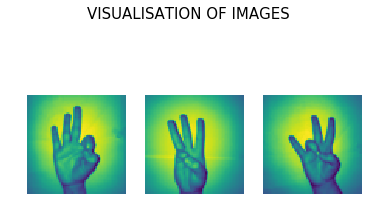

In [8]:
img_size = 64
plt.subplot(1, 3, 1)
plt.imshow(data_x[200].reshape(img_size, img_size))
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(data_x[800].reshape(img_size, img_size))
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(data_x[600].reshape(img_size, img_size))
plt.suptitle("VISUALISATION OF IMAGES", fontsize=15)
plt.axis('off')

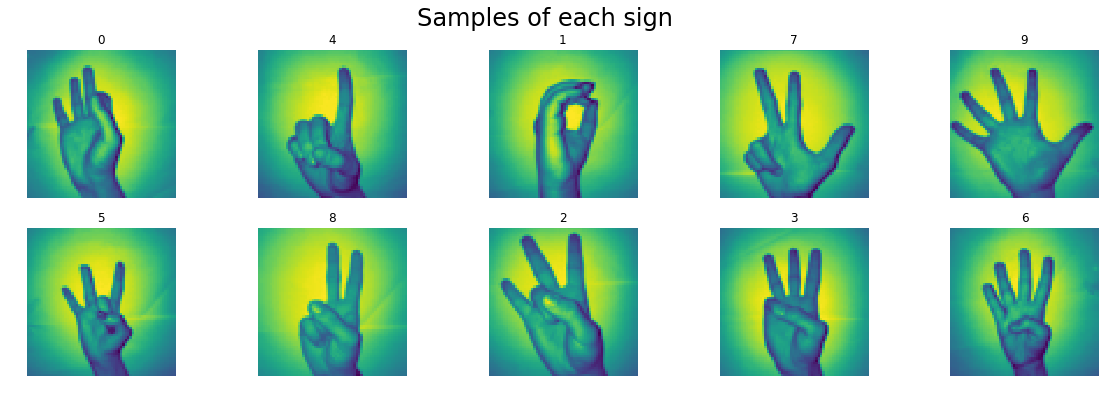

In [9]:
plt.figure(figsize=(20,6))
plt.subplot(2,5,1)
plt.title(data_y[0].argmax())
plt.imshow(data_x[0])
plt.axis("off")
plt.subplot(2,5,2)
plt.title(data_y[1000].argmax())
plt.imshow(data_x[1000])
plt.axis("off")
plt.subplot(2,5,3)
plt.title(data_y[222].argmax())
plt.imshow(data_x[222])
plt.axis("off")
plt.subplot(2,5,4)
plt.title(data_y[1500].argmax())
plt.imshow(data_x[1500])
plt.axis("off")
plt.subplot(2,5,5)
plt.title(data_y[2000].argmax())
plt.imshow(data_x[2000])
plt.axis("off")
plt.subplot(2,5,6)
plt.title(data_y[1200].argmax())
plt.imshow(data_x[1200])
plt.axis("off")
plt.subplot(2,5,7)
plt.title(data_y[1700].argmax())
plt.imshow(data_x[1700])
plt.axis("off")
plt.subplot(2,5,8)
plt.title(data_y[500].argmax())
plt.imshow(data_x[500])
plt.axis("off")
plt.subplot(2,5,9)
plt.title(data_y[700].argmax())
plt.imshow(data_x[700])
plt.axis("off")
plt.subplot(2,5,10)
plt.title(data_y[1400].argmax())
plt.imshow(data_x[1400])
plt.axis("off")
plt.suptitle("Samples of each sign", fontsize=24)
plt.show()

Spliting into test-20% and train-80% of data

In [10]:
x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.2, random_state=10)
print("x train shape: {}".format(x_train.shape))
print("y train shape: {}".format(y_train.shape))
print("x test shape: {}".format(x_test.shape))
print("y test shape: {}".format(y_test.shape))

x train shape: (1649, 64, 64)
y train shape: (1649, 10)
x test shape: (413, 64, 64)
y test shape: (413, 10)


Reshaping into 3D as required by Keras

In [11]:
x_train = x_train.reshape(-1,64,64,1)
x_test = x_test.reshape(-1,64,64,1)
print("x train shape: {}".format(x_train.shape))
print("x test shape: {}".format(x_test.shape))

x train shape: (1649, 64, 64, 1)
x test shape: (413, 64, 64, 1)


Creating Convolutional Neural Network Model, 
Augmenting data randomly: 10% zoom, horizontall and vertical flip, image rotation

In [12]:
CNN_model = Sequential()

CNN_model.add(Conv2D(filters = 8, kernel_size = (5,5), padding = 'Same', activation = 'relu', input_shape = (64,64,1)))
CNN_model.add(MaxPool2D(pool_size=(2,2)))
CNN_model.add(BatchNormalization())
CNN_model.add(Dropout(0.25))

CNN_model.add(Conv2D(filters = 16, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
CNN_model.add(MaxPool2D(pool_size=(2,2)))
CNN_model.add(BatchNormalization())
CNN_model.add(Dropout(0.25))

CNN_model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
CNN_model.add(MaxPool2D(pool_size=(2,2)))
CNN_model.add(BatchNormalization())
CNN_model.add(Dropout(0.25))

CNN_model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
CNN_model.add(MaxPool2D(pool_size=(2,2)))
CNN_model.add(BatchNormalization())
CNN_model.add(Dropout(0.25))

CNN_model.add(Flatten())
CNN_model.add(Dense(256, activation = 'relu'))
CNN_model.add(BatchNormalization())
CNN_model.add(Dropout(0.25))

CNN_model.add(Dense(256, activation = 'relu'))
CNN_model.add(BatchNormalization())
CNN_model.add(Dropout(0.25))

CNN_model.add(Dense(256, activation = 'relu'))
CNN_model.add(BatchNormalization())
CNN_model.add(Dropout(0.25))
CNN_model.add(Dense(10, activation = 'softmax'))

epochs = 100 
batch_size = 10

optimizer = Adam(lr=0.001, beta_1=0.9, beta_2=0.999)
CNN_model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])
datagen = ImageDataGenerator(rotation_range=10, zoom_range = 0.5, width_shift_range=0.5, height_shift_range=0.5, 
                             horizontal_flip=False,  vertical_flip=False)  
datagen.fit(x_train)

results = CNN_model.fit_generator(datagen.flow(x_train,y_train, batch_size=batch_size),
         epochs = epochs, validation_data = (x_test,y_test), steps_per_epoch=x_train.shape[0]//batch_size)


Epoch 1/100
164/164 [==============================] - 6s 39ms/step - loss: 3.1046 - accuracy: 0.0970 - val_loss: 2.4199 - val_accuracy: 0.1041
Epoch 2/100
164/164 [==============================] - 4s 22ms/step - loss: 2.7890 - accuracy: 0.1056 - val_loss: 2.5568 - val_accuracy: 0.0920
Epoch 3/100
164/164 [==============================] - 4s 22ms/step - loss: 2.6747 - accuracy: 0.1025 - val_loss: 2.4425 - val_accuracy: 0.0920
Epoch 4/100
164/164 [==============================] - 4s 22ms/step - loss: 2.6264 - accuracy: 0.1007 - val_loss: 2.4203 - val_accuracy: 0.0872
Epoch 5/100
164/164 [==============================] - 4s 22ms/step - loss: 2.5341 - accuracy: 0.1062 - val_loss: 2.4061 - val_accuracy: 0.1138
Epoch 6/100
164/164 [==============================] - 4s 22ms/step - loss: 2.4884 - accuracy: 0.1123 - val_loss: 2.3697 - val_accuracy: 0.1211
Epoch 7/100
164/164 [==============================] - 4s 24ms/step - loss: 2.4354 - accuracy: 0.1208 - val_loss: 2.3905 - val_accuracy

164/164 [==============================] - 7s 41ms/step - loss: 1.6110 - accuracy: 0.4029 - val_loss: 0.8819 - val_accuracy: 0.6901
Epoch 57/100
164/164 [==============================] - 7s 43ms/step - loss: 1.5937 - accuracy: 0.4021 - val_loss: 0.6196 - val_accuracy: 0.7700
Epoch 58/100
164/164 [==============================] - 7s 40ms/step - loss: 1.5472 - accuracy: 0.4411 - val_loss: 0.5385 - val_accuracy: 0.8402
Epoch 59/100
164/164 [==============================] - 7s 40ms/step - loss: 1.5005 - accuracy: 0.4484 - val_loss: 0.5768 - val_accuracy: 0.8329
Epoch 60/100
164/164 [==============================] - 7s 42ms/step - loss: 1.5405 - accuracy: 0.4433 - val_loss: 0.4837 - val_accuracy: 0.8475
Epoch 61/100
164/164 [==============================] - 7s 42ms/step - loss: 1.4921 - accuracy: 0.4649 - val_loss: 0.9537 - val_accuracy: 0.6586
Epoch 62/100
164/164 [==============================] - 7s 43ms/step - loss: 1.5269 - accuracy: 0.4417 - val_loss: 0.6398 - val_accuracy: 0.753

In [13]:
scores = CNN_model.evaluate(x_test, y_test, verbose=0)

print("{}: {:.2f}%".format("accuracy", scores[1]*100))

accuracy: 94.43%


References:

1.https://arxiv.org/ftp/arxiv/papers/2011/2011.08927.pdf 
2.https://www.coursera.org/learn/convolutional-neural-networks
3.https://www.cs.middlebury.edu/~tgyalpo/cs451/SL_recognition.html  
4.https://software.intel.com/en-us/ai-academy/students/kits/deep-learning-501

    